# GAN (Generative Adversarial Network) - 초급용
## 경쟁하며 배우는 이미지 생성 AI

### 학습 목표
- GAN의 핵심 개념 이해하기 (Generator vs Discriminator)
- 두 네트워크가 경쟁하며 학습하는 과정 체험하기
- 실제 이미지 생성 결과 확인하기

## STEP 1️⃣ : 필요한 라이브러리 불러오기

딥러닝을 위한 기본 도구들을 가져옵니다.

In [1]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [2]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1

런타임 다시 시작

In [1]:
# PyTorch: 딥러닝 프레임워크
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# 데이터셋 관련
from torchvision import datasets, transforms

# 시각화 도구
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

In [3]:
# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

## STEP 2️⃣ : 기본 설정하기

학습에 필요한 기본값들을 정해줍니다.

In [4]:
# GPU가 있으면 사용하고, 없으면 CPU 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 중인 디바이스: {device}")

# 하이퍼파라미터 (학습 설정값)
batch_size = 128        # 한 번에 처리할 이미지 개수
learning_rate = 0.0002  # 학습 속도 (GAN은 보통 작게 설정)
num_epochs = 30         # 전체 데이터를 몇 번 반복할지
latent_dim = 100        # 노이즈 벡터의 크기 (랜덤 입력)

print(f"\n배치 크기: {batch_size}")
print(f"학습률: {learning_rate}")
print(f"에포크 수: {num_epochs}")
print(f"잠재 차원: {latent_dim}")

사용 중인 디바이스: cuda

배치 크기: 128
학습률: 0.0002
에포크 수: 30
잠재 차원: 100


## STEP 3️⃣ : 데이터 준비하기 (MNIST 손글씨)

0~9 숫자 손글씨 이미지를 다운로드하고 준비합니다.

In [6]:
# 이미지 전처리: 값을 -1 ~ 1 사이로 정규화
# GAN에서는 보통 -1 ~ 1 범위를 사용합니다
transform = transforms.Compose([
    transforms.ToTensor(),  # 0~1로 변환
    transforms.Normalize([0.5], [0.5])  # -1~1로 변환
])

# MNIST 데이터셋 다운로드
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# 데이터 로더 생성
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
print()
print(f"총 학습 이미지 수: {len(train_dataset)}장")
print(f"이미지 크기: 28 x 28 픽셀")


총 학습 이미지 수: 60000장
이미지 크기: 28 x 28 픽셀


## STEP 4️⃣ : 샘플 이미지 확인하기

실제 데이터가 어떻게 생겼는지 확인해봅시다.

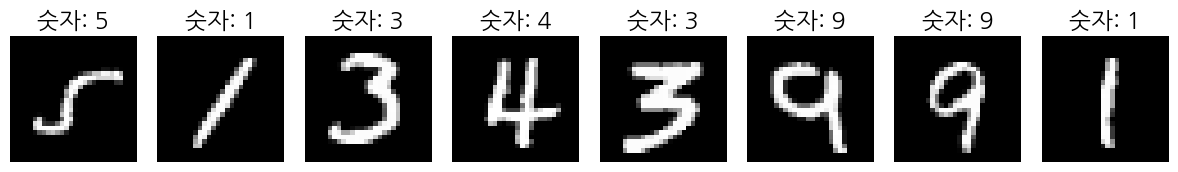

이미지 형태: torch.Size([1, 28, 28])
픽셀 값 범위: [-1.00 ~ 1.00]


In [8]:
# 첫 번째 배치의 이미지 가져오기
sample_images, sample_labels = next(iter(train_loader))

# -1~1 범위를 0~1로 복원 (시각화용)
sample_images_display = sample_images * 0.5 + 0.5

# 8개 이미지 시각화
plt.figure(figsize=(12, 3))
for i in range(8):
    plt.subplot(1, 8, i+1)
    plt.imshow(sample_images_display[i][0], cmap='gray')
    plt.title(f"숫자: {sample_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

print(f"이미지 형태: {sample_images[0].shape}")  # [1, 28, 28] chw
print(f"픽셀 값 범위: [{sample_images.min():.2f} ~ {sample_images.max():.2f}]")

## STEP 5️⃣ : Generator (생성자) 만들기

**Generator의 역할**: 랜덤 노이즈에서 가짜 이미지 만들기

랜덤 벡터(100차원) → 가짜 이미지(28x28=784차원)

In [9]:
# Generator 네트워크 구조
# 입력: 100차원 랜덤 노이즈
# 출력: 784차원 (28x28 이미지)

generator = nn.Sequential(
    # 첫 번째 층: 100 → 256
    nn.Linear(latent_dim, 256),
    nn.LeakyReLU(0.2),  # LeakyReLU: ReLU보다 안정적 (음수를 완전히 0으로 만들지 않음)

    # 두 번째 층: 256 → 512
    nn.Linear(256, 512),
    nn.LeakyReLU(0.2),

    # 세 번째 층: 512 → 784
    nn.Linear(512, 784),
    nn.Tanh()  # 출력을 -1 ~ 1 사이로 만들기 (실제 이미지와 같은 범위)
)

generator = generator.to(device)

print(f"입력: {latent_dim}차원 → 출력: 784차원 (28x28 이미지)")
print("\n역할: '위조지폐범' - 진짜 같은 가짜 이미지 만들기")

입력: 100차원 → 출력: 784차원 (28x28 이미지)

역할: '위조지폐범' - 진짜 같은 가짜 이미지 만들기


## STEP 6️⃣ : Discriminator (판별자) 만들기

**Discriminator의 역할**: 이미지가 진짜인지 가짜인지 구분하기

이미지(28x28=784차원) → 진짜/가짜 확률(1개 값)

In [10]:
# Discriminator 네트워크 구조
# 입력: 784차원 (28x28 이미지)
# 출력: 1차원 (진짜일 확률 0~1)

discriminator = nn.Sequential(
    # 첫 번째 층: 784 → 512
    nn.Linear(784, 512),
    nn.LeakyReLU(0.2),
    nn.Dropout(0.3),  # Dropout: 과적합 방지 (랜덤하게 30% 뉴런 끄기)

    # 두 번째 층: 512 → 256
    nn.Linear(512, 256),
    nn.LeakyReLU(0.2),
    nn.Dropout(0.3),

    # 세 번째 층: 256 → 1
    nn.Linear(256, 1),
    nn.Sigmoid()  # 출력을 0~1 사이 확률로 만들기
)

discriminator = discriminator.to(device)

print(f"입력: 784차원 → 출력: 1차원 (진짜일 확률)")
print("\n역할: '감정사' - 진짜와 가짜 구별하기")

입력: 784차원 → 출력: 1차원 (진짜일 확률)

역할: '감정사' - 진짜와 가짜 구별하기


## STEP 7️⃣ : Loss 함수와 Optimizer 설정하기

GAN은 **두 개의 네트워크를 따로 학습**시킵니다!

In [11]:
# Loss 함수: Binary Cross Entropy (이진 분류)
# 진짜(1) vs 가짜(0)를 구분하는 문제
criterion = nn.BCELoss()

# Optimizer: Generator와 Discriminator 각각 따로!
optimizer_G = optim.Adam(generator.parameters(), lr=learning_rate, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999))

print("\n학습 전략:")
print("1. Discriminator: 진짜는 1, 가짜는 0으로 분류하도록 학습")
print("2. Generator: Discriminator를 속이도록 학습 (가짜를 1로 판별하게 만들기)")
# betas : b1, b2
# 일반적으로 betas default가 betas=(0.9, 0.999) >> Gan에서 betas=(0.5, 0.999) 사용
# 모멘텀 b1 (beta 1) 0.9 : 방향 (과거의 기울기 (gradient) 정보 얼마나 유지할거니)
# 모멘텀 b2 (beta 2) = 0.999: 보폭 (기울기를 제곱한 값을 누적)
# gan은 b1(beta1)을 0.5 사용 : 생성자(G)와 판별자(D) 서로 경쟁 >> 균형 찾아가는 구조



학습 전략:
1. Discriminator: 진짜는 1, 가짜는 0으로 분류하도록 학습
2. Generator: Discriminator를 속이도록 학습 (가짜를 1로 판별하게 만들기)


## STEP 8️⃣ : GAN 학습의 핵심 개념 이해하기

학습 전에 GAN의 학습 과정을 이해해봅시다.

In [12]:
print("\n PHASE 1: Discriminator 학습")
print("   1-1. 진짜 이미지를 보여주고 → '진짜(1)'라고 판별하도록 학습")
print("   1-2. Generator가 만든 가짜 이미지 → '가짜(0)'라고 판별하도록 학습")
print("   → Loss_D = Loss(진짜, 1) + Loss(가짜, 0)")
print()
print(" PHASE 2: Generator 학습")
print("   2-1. 새로운 가짜 이미지 생성")
print("   2-2. Discriminator가 '진짜(1)'라고 착각하도록 학습")
print("   → Loss_G = Loss(가짜, 1) [Discriminator를 속이기!]")
print()
print(" 핵심: 두 네트워크가 서로 경쟁하며 점점 똑똑해집니다!")
print("="*60)


 PHASE 1: Discriminator 학습
   1-1. 진짜 이미지를 보여주고 → '진짜(1)'라고 판별하도록 학습
   1-2. Generator가 만든 가짜 이미지 → '가짜(0)'라고 판별하도록 학습
   → Loss_D = Loss(진짜, 1) + Loss(가짜, 0)

 PHASE 2: Generator 학습
   2-1. 새로운 가짜 이미지 생성
   2-2. Discriminator가 '진짜(1)'라고 착각하도록 학습
   → Loss_G = Loss(가짜, 1) [Discriminator를 속이기!]

 핵심: 두 네트워크가 서로 경쟁하며 점점 똑똑해집니다!


## STEP 9️⃣ : 학습 전 Generator 성능 확인

학습하기 전에 Generator가 만드는 이미지를 봅시다. (당연히 엉망일 것입니다!)

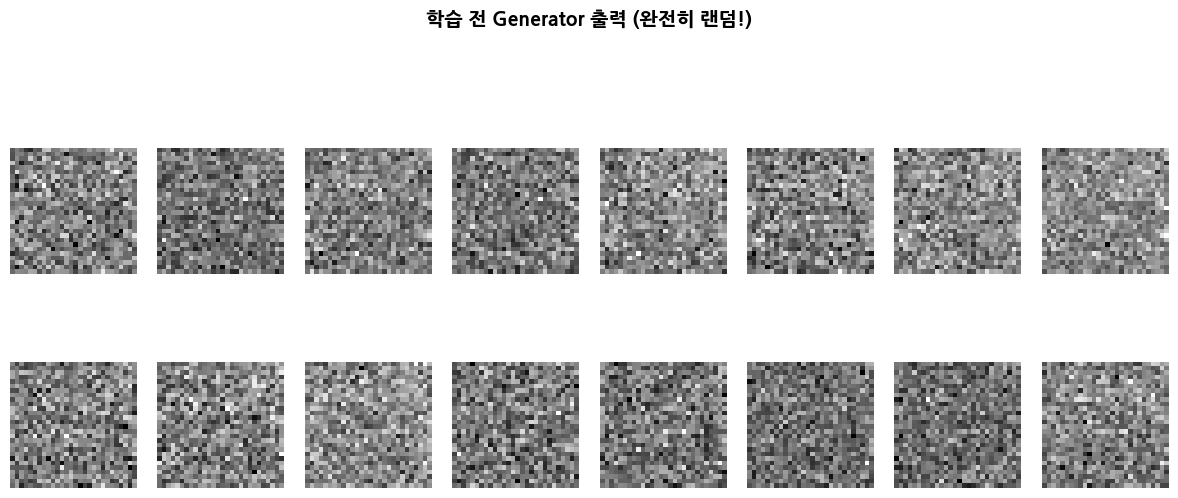

학습 전에는 의미 없는 노이즈만 생성됩니다.


In [13]:
generator.eval()

with torch.no_grad():
    # 랜덤 노이즈 생성
    test_noise = torch.randn(16, latent_dim).to(device)
    # 가짜 이미지 생성
    fake_images_before = generator(test_noise)
    fake_images_before = fake_images_before.view(-1, 1, 28, 28).cpu()
    # -1~1 범위를 0~1로 변환 (시각화용)
    fake_images_before = fake_images_before * 0.5 + 0.5

# 시각화
plt.figure(figsize=(12, 6))
for i in range(16):
    plt.subplot(2, 8, i+1)
    plt.imshow(fake_images_before[i][0], cmap='gray')
    plt.axis('off')
plt.suptitle('학습 전 Generator 출력 (완전히 랜덤!)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("학습 전에는 의미 없는 노이즈만 생성됩니다.")

## STEP 🔟 : GAN 학습 시작! (메인 훈련 루프)

이제 진짜 GAN 학습을 시작합니다. 시간이 좀 걸릴 수 있습니다!

Epoch [1/30] - D_loss: 0.8788, G_loss: 1.3772
Epoch [2/30] - D_loss: 0.6270, G_loss: 2.4445
Epoch [3/30] - D_loss: 0.6673, G_loss: 2.2731
Epoch [4/30] - D_loss: 0.5950, G_loss: 2.5759
Epoch [5/30] - D_loss: 0.6088, G_loss: 2.5709


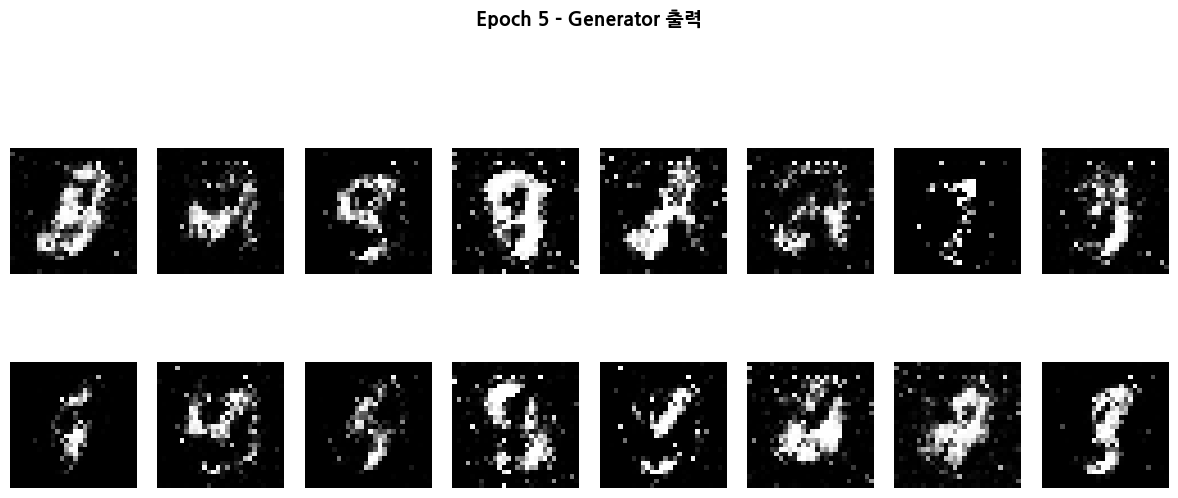

Epoch [6/30] - D_loss: 0.6048, G_loss: 2.5699
Epoch [7/30] - D_loss: 0.5777, G_loss: 2.8305
Epoch [8/30] - D_loss: 0.5452, G_loss: 2.8408
Epoch [9/30] - D_loss: 0.5403, G_loss: 2.8352
Epoch [10/30] - D_loss: 0.5566, G_loss: 2.6977


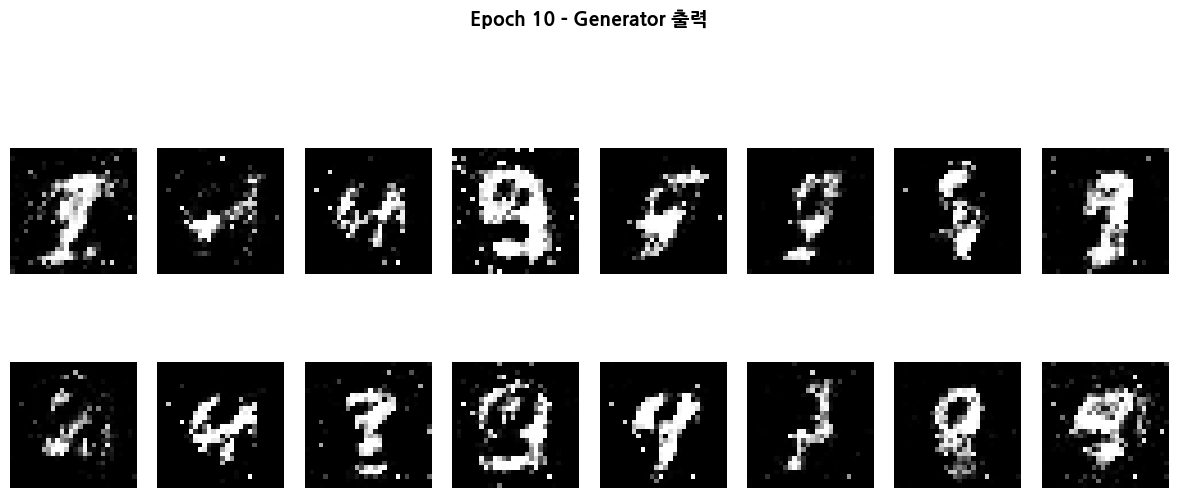

Epoch [11/30] - D_loss: 0.5832, G_loss: 2.5002
Epoch [12/30] - D_loss: 0.5896, G_loss: 2.5008
Epoch [13/30] - D_loss: 0.6557, G_loss: 2.2570
Epoch [14/30] - D_loss: 0.7102, G_loss: 2.0637
Epoch [15/30] - D_loss: 0.7852, G_loss: 1.8180


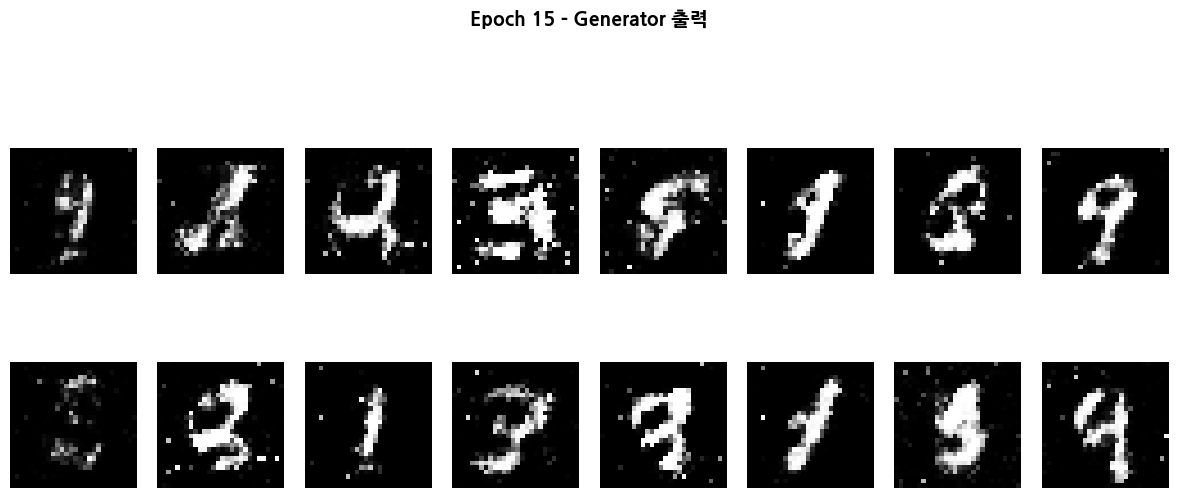

Epoch [16/30] - D_loss: 0.8507, G_loss: 1.6224
Epoch [17/30] - D_loss: 0.8796, G_loss: 1.5334
Epoch [18/30] - D_loss: 0.9045, G_loss: 1.4826
Epoch [19/30] - D_loss: 0.9323, G_loss: 1.4251
Epoch [20/30] - D_loss: 0.9522, G_loss: 1.3946


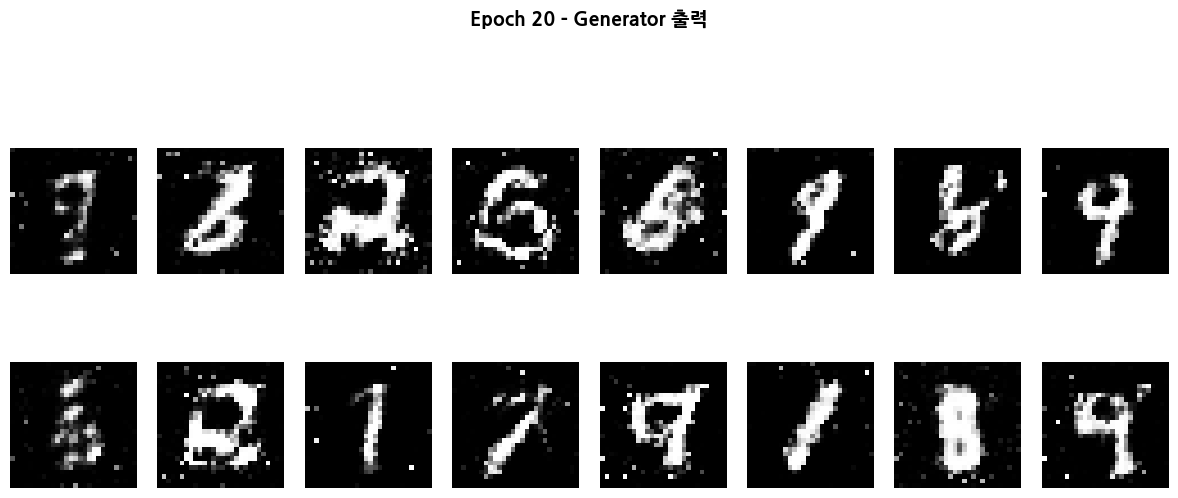

Epoch [21/30] - D_loss: 0.9758, G_loss: 1.3610
Epoch [22/30] - D_loss: 1.0054, G_loss: 1.3112
Epoch [23/30] - D_loss: 1.0147, G_loss: 1.2828
Epoch [24/30] - D_loss: 1.0440, G_loss: 1.2375
Epoch [25/30] - D_loss: 1.0524, G_loss: 1.2213


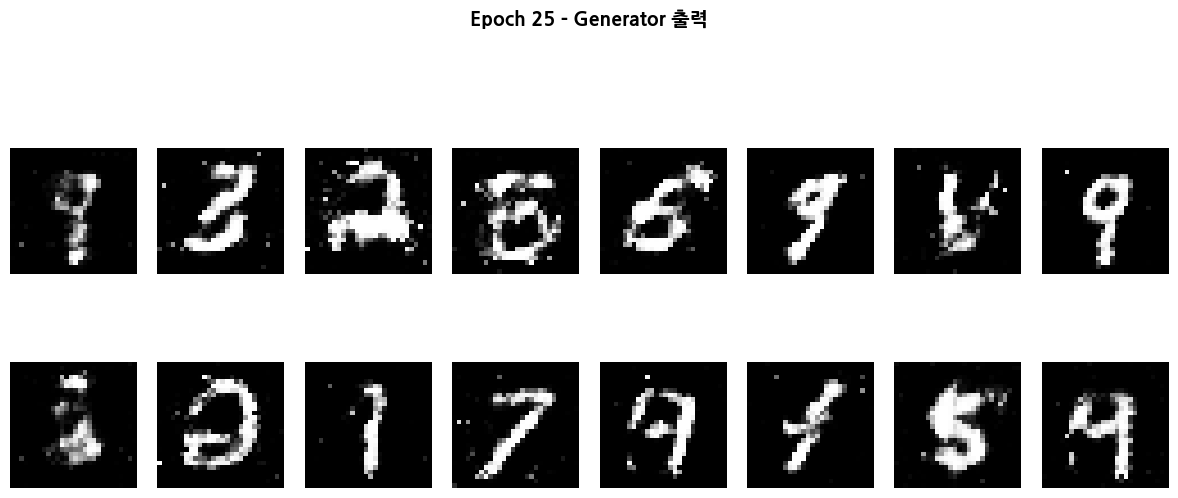

Epoch [26/30] - D_loss: 1.0711, G_loss: 1.1921
Epoch [27/30] - D_loss: 1.0773, G_loss: 1.1922
Epoch [28/30] - D_loss: 1.0824, G_loss: 1.1779
Epoch [29/30] - D_loss: 1.0947, G_loss: 1.1703
Epoch [30/30] - D_loss: 1.0997, G_loss: 1.1512


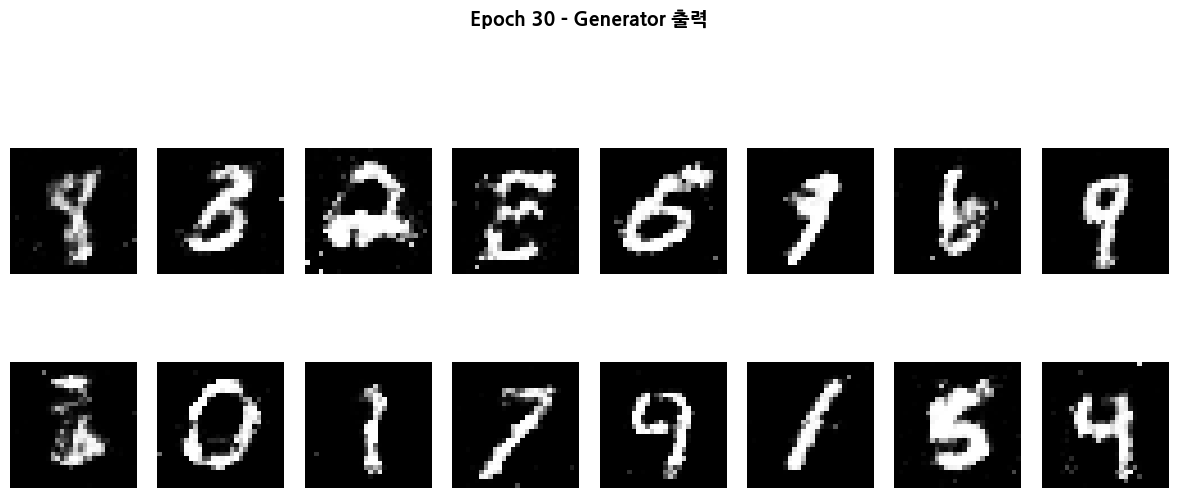

In [14]:
# 학습 모드로 전환
generator.train()
discriminator.train()

# 손실값 기록용 리스트
G_losses = []
D_losses = []

# 학습 중간 결과 저장용
fixed_noise = torch.randn(16, latent_dim).to(device)  # 고정된 노이즈 (비교용)

for epoch in range(num_epochs):
    epoch_G_loss = 0
    epoch_D_loss = 0

    for batch_idx, (real_images, _) in enumerate(train_loader):
        current_batch_size = real_images.size(0)

        # 데이터를 GPU/CPU로 이동하고 1차원으로 펼치기
        real_images = real_images.view(current_batch_size, -1).to(device)

        # 레이블 생성 (진짜: 1, 가짜: 0)
        real_labels = torch.ones(current_batch_size, 1).to(device)
        fake_labels = torch.zeros(current_batch_size, 1).to(device)

        # ============================================
        #  PHASE 1: Discriminator 학습
        # ============================================

        # 1-1. 진짜 이미지로 학습
        outputs_real = discriminator(real_images)
        loss_D_real = criterion(outputs_real, real_labels)

        # 1-2. 가짜 이미지로 학습
        noise = torch.randn(current_batch_size, latent_dim).to(device)
        fake_images = generator(noise)
        outputs_fake = discriminator(fake_images.detach())  # detach: Generator 학습 안 함
        loss_D_fake = criterion(outputs_fake, fake_labels)

        # Discriminator 총 손실
        loss_D = loss_D_real + loss_D_fake

        # Discriminator 업데이트
        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # ============================================
        #  PHASE 2: Generator 학습
        # ============================================

        # 새로운 가짜 이미지 생성
        noise = torch.randn(current_batch_size, latent_dim).to(device)
        fake_images = generator(noise)

        # Discriminator가 가짜를 진짜라고 착각하도록!
        outputs = discriminator(fake_images)
        loss_G = criterion(outputs, real_labels)  # 가짜를 1(진짜)로 판별하게 만들기

        # Generator 업데이트
        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

        # 손실값 누적
        epoch_G_loss += loss_G.item()
        epoch_D_loss += loss_D.item()

    # 에포크별 평균 손실
    avg_G_loss = epoch_G_loss / len(train_loader)
    avg_D_loss = epoch_D_loss / len(train_loader)
    G_losses.append(avg_G_loss)
    D_losses.append(avg_D_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - D_loss: {avg_D_loss:.4f}, G_loss: {avg_G_loss:.4f}")

    # 5 에포크마다 중간 결과 시각화
    if (epoch + 1) % 5 == 0:
        generator.eval()
        with torch.no_grad():
            fake_images_progress = generator(fixed_noise)
            fake_images_progress = fake_images_progress.view(-1, 1, 28, 28).cpu()
            fake_images_progress = fake_images_progress * 0.5 + 0.5

        plt.figure(figsize=(12, 6))
        for i in range(16):
            plt.subplot(2, 8, i+1)
            plt.imshow(fake_images_progress[i][0], cmap='gray')
            plt.axis('off')
        plt.suptitle(f'Epoch {epoch+1} - Generator 출력', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        generator.train()


## STEP 1️⃣1️⃣ : 학습 과정 시각화하기

Generator와 Discriminator의 손실 변화를 확인해봅시다.

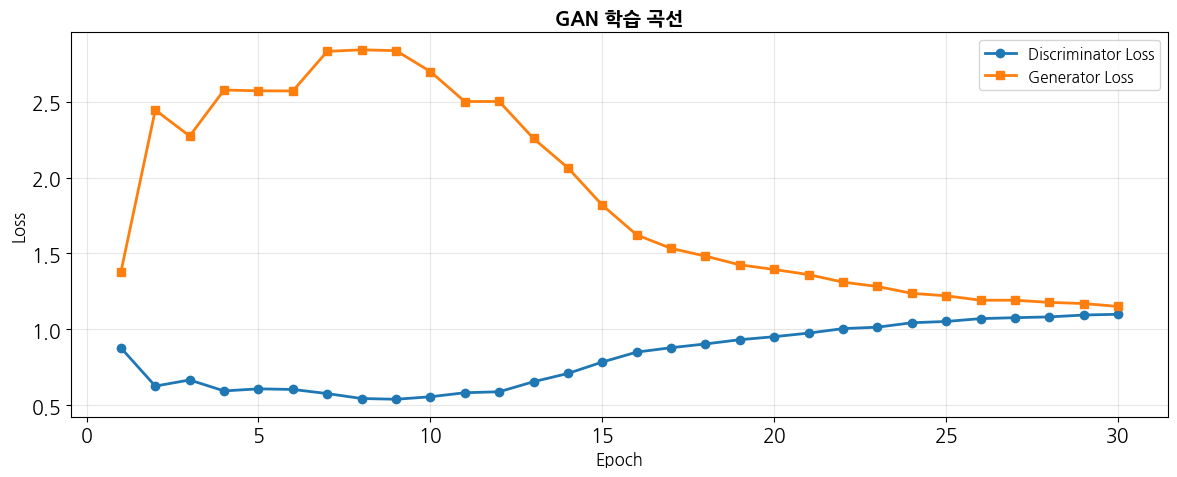

해석:
- Discriminator Loss가 너무 낮으면: 판별자가 너무 강함 (생성자가 속이기 어려움)
- Generator Loss가 너무 낮으면: 생성자가 너무 강함 (판별자를 쉽게 속임)
- 이상적: 두 손실이 균형을 이루며 함께 감소


In [15]:
plt.figure(figsize=(12, 5))

plt.plot(range(1, num_epochs+1), D_losses, label='Discriminator Loss', linewidth=2, marker='o')
plt.plot(range(1, num_epochs+1), G_losses, label='Generator Loss', linewidth=2, marker='s')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('GAN 학습 곡선', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("해석:")
print("- Discriminator Loss가 너무 낮으면: 판별자가 너무 강함 (생성자가 속이기 어려움)")
print("- Generator Loss가 너무 낮으면: 생성자가 너무 강함 (판별자를 쉽게 속임)")
print("- 이상적: 두 손실이 균형을 이루며 함께 감소")

## STEP 1️⃣2️⃣ : 최종 생성 이미지 확인하기!

학습이 완료된 Generator로 새로운 이미지를 만들어봅시다!

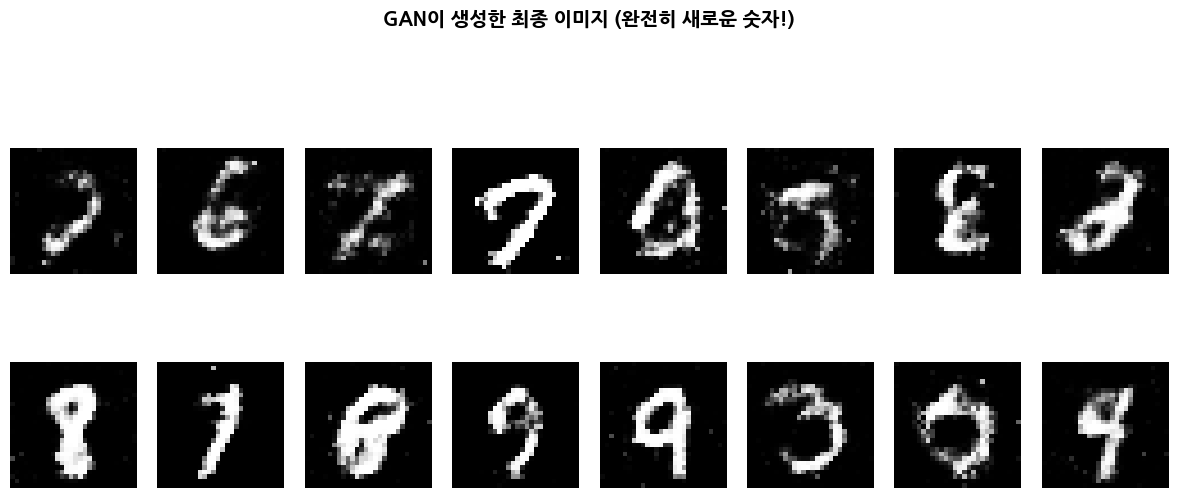

 GAN이 실제 데이터의 패턴을 학습하여 새로운 이미지를 만들었습니다!


In [16]:
generator.eval()

with torch.no_grad():
    # 랜덤 노이즈에서 이미지 생성
    random_noise = torch.randn(16, latent_dim).to(device)
    generated_images = generator(random_noise)
    generated_images = generated_images.view(-1, 1, 28, 28).cpu()
    generated_images = generated_images * 0.5 + 0.5

# 시각화
plt.figure(figsize=(12, 6))
for i in range(16):
    plt.subplot(2, 8, i+1)
    plt.imshow(generated_images[i][0], cmap='gray')
    plt.axis('off')

plt.suptitle('GAN이 생성한 최종 이미지 (완전히 새로운 숫자!)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(" GAN이 실제 데이터의 패턴을 학습하여 새로운 이미지를 만들었습니다!")

## STEP 1️⃣3️⃣ : 학습 전 vs 학습 후 비교

같은 노이즈에서 생성한 결과를 비교해봅시다.

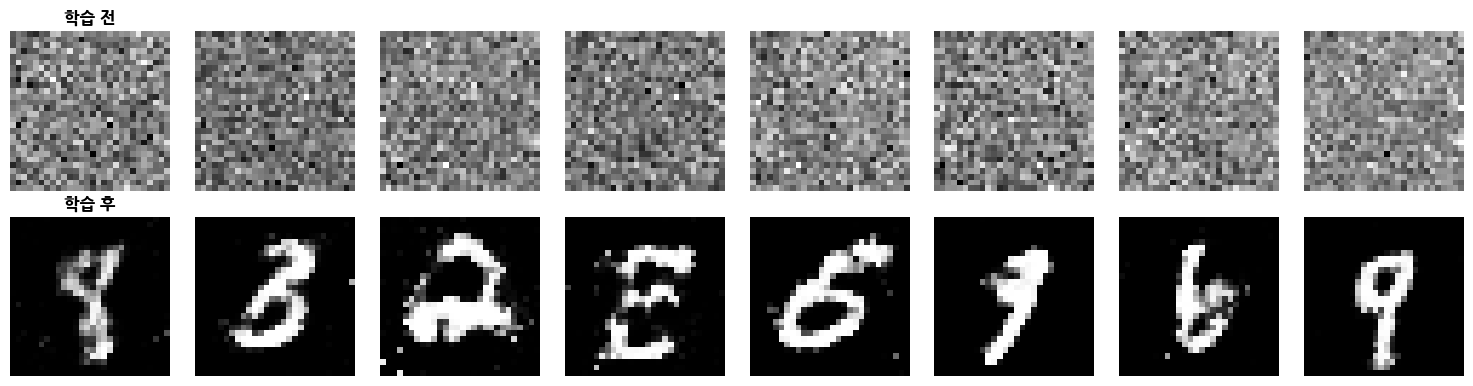

같은 랜덤 시드에서 출발했지만, 학습 후에는 의미 있는 숫자 형태를 생성합니다!


In [17]:
generator.eval()

with torch.no_grad():
    # 학습 후 이미지 (고정된 노이즈 사용)
    fake_images_after = generator(fixed_noise)
    fake_images_after = fake_images_after.view(-1, 1, 28, 28).cpu()
    fake_images_after = fake_images_after * 0.5 + 0.5

# 비교 시각화
fig, axes = plt.subplots(2, 8, figsize=(15, 4))

for i in range(8):
    # 학습 전
    axes[0, i].imshow(fake_images_before[i][0], cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('학습 전', fontweight='bold', fontsize=12)

    # 학습 후
    axes[1, i].imshow(fake_images_after[i][0], cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('학습 후', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("같은 랜덤 시드에서 출발했지만, 학습 후에는 의미 있는 숫자 형태를 생성합니다!")

## STEP 1️⃣4️⃣ : Discriminator 성능 테스트

학습된 Discriminator가 진짜와 가짜를 얼마나 잘 구분하는지 확인해봅시다.

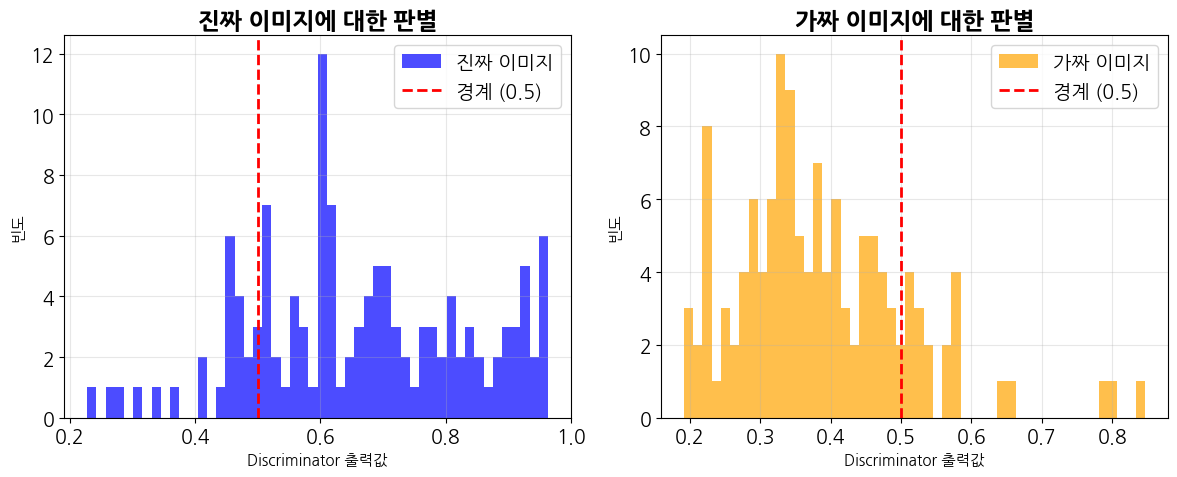

진짜 이미지 평균 점수: 0.6640
가짜 이미지 평균 점수: 0.3873

 이상적인 경우:
- 진짜 이미지는 1에 가까움 (Discriminator가 진짜로 인식)
- 가짜 이미지는 0.5 근처 (Generator가 Discriminator를 잘 속임)


In [19]:
discriminator.eval()
generator.eval()

with torch.no_grad():
    # 진짜 이미지 가져오기
    real_test_images, _ = next(iter(train_loader))
    real_test_images = real_test_images.view(real_test_images.size(0), -1).to(device)

    # 가짜 이미지 생성
    test_noise = torch.randn(batch_size, latent_dim).to(device)
    fake_test_images = generator(test_noise)

    # Discriminator 판별
    real_scores = discriminator(real_test_images).cpu().numpy()
    fake_scores = discriminator(fake_test_images).cpu().numpy()

# 결과 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(real_scores, bins=50, alpha=0.7, color='blue', label='진짜 이미지')
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='경계 (0.5)')
plt.xlabel('Discriminator 출력값', fontsize=11)
plt.ylabel('빈도', fontsize=11)
plt.title('진짜 이미지에 대한 판별', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(fake_scores, bins=50, alpha=0.7, color='orange', label='가짜 이미지')
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='경계 (0.5)')
plt.xlabel('Discriminator 출력값', fontsize=11)
plt.ylabel('빈도', fontsize=11)
plt.title('가짜 이미지에 대한 판별', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"진짜 이미지 평균 점수: {real_scores.mean():.4f}")
print(f"가짜 이미지 평균 점수: {fake_scores.mean():.4f}")
print("\n 이상적인 경우:")
print("- 진짜 이미지는 1에 가까움 (Discriminator가 진짜로 인식)")
print("- 가짜 이미지는 0.5 근처 (Generator가 Discriminator를 잘 속임)")
# 왜 0.5 일까요? 판별자의 분류 기준 : 시그모이드 (sigmoid)
# 판별자 진짜일 확률이 0.5 이상이면 진짜, 안 되면 가짜

## 🎓 학습 마무리

###  오늘 배운 내용

1. **GAN의 구조**
   - Generator: 노이즈 → 가짜 이미지
   - Discriminator: 이미지 → 진짜/가짜 판별

2. **GAN의 학습 원리**
   - Adversarial Learning (적대적 학습)
   - 두 네트워크가 경쟁하며 성장
   - Generator는 Discriminator를 속이려 함
   - Discriminator는 진짜와 가짜를 구분하려 함

3. **GAN의 특징**
   - 매우 사실적인 이미지 생성 가능
   - 학습이 불안정할 수 있음
   - 두 네트워크의 균형이 중요


### GAN의 발전

- **DCGAN**: CNN 구조 사용
- **StyleGAN**: 고품질 얼굴 생성
- **CycleGAN**: 이미지 스타일 변환
- **Pix2Pix**: 조건부 이미지 생성

